In [4]:
from typing import TypedDict, Annotated
from dotenv import load_dotenv

import requests
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from IPython.display import Image, display
import os
load_dotenv()

GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
GITHUB_REPO  = "rahul8879/e-comm-agentic-demo"
HEADERS = {
    "Accept": "application/vnd.github.v3+json",
    "Authorization": f"'token {GITHUB_TOKEN}'",
}

BASE_URL = f"https://api.github.com/repos/{GITHUB_REPO}"
r = requests.get(
    BASE_URL, headers=HEADERS
)

r.status_code

200

In [5]:
PR_NUMBER = 1

In [22]:
# r.json()
@tool
def get_pr_details() -> dict:
    """Fetch PR title, description, author, and current status."""
    url = f"{BASE_URL}/pulls/{PR_NUMBER}"
    r = requests.get(url, headers=HEADERS)
    pr = r.json()
    return {
        "title":       pr.get("title"),
        "description": pr.get("body", "No description provided"),
        "author":      pr["user"]["login"],
        "state":       pr.get("state"),
        "branch":      pr["head"]["ref"],
    }

@tool
def get_pr_files() -> list:
    """List all files changed in the PR with their status and patch."""
    url = f"{BASE_URL}/pulls/{PR_NUMBER}/files"
    r = requests.get(url, headers=HEADERS)
    files = []
    for f in r.json():
        files.append({
            "filename": f.get("filename"),
            "status":   f.get("status"),       # added / modified / removed
            "changes":  f.get("changes"),
            "patch":    f.get("patch", "")[:2000],  # limit patch size
        })
    return files
@tool
def get_file_content(file_path: str) -> str:
    """Fetch the full content of a file from the repo's default branch."""
    url = f"{BASE_URL}/contents/{file_path}"
    r = requests.get(url, headers=HEADERS)
    data = r.json()
    if "content" not in data:
        return f"Could not fetch: {file_path}"
    return base64.b64decode(data["content"]).decode("utf-8")


# @tool
def post_pr_comment(comment: str) -> dict:
    """Post a review comment on the PR."""
    url = f"{BASE_URL}/issues/{PR_NUMBER}/comments"
    payload = {"body": comment}
    r = requests.post(url, headers=HEADERS, json=payload)
    return {"status": r.status_code, "comment_url": r.json().get("html_url")}


post_pr_comment("Thanks for the PR!")

{'status': 401, 'comment_url': None}

In [9]:
tools = [get_pr_details, get_pr_files, get_file_content, post_pr_comment]

In [10]:
class State(TypedDict):
    messages : Annotated[list, add_messages]
    pr_number : int
    verdict : str

llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools)

In [ ]:
SYSTEM_PROMPT = """You are CodeSentinel — an expert PR code reviewer.

Always post a comment in this format:
## 🤖 CodeSentinel Review

### ✅ What looks good
- ...

### ⚠️ Issues Found
- ...

### 🔧 Suggestions
- ...

### 📊 Verdict
APPROVED / NEEDS CHANGES
"""



In [12]:
def agent_node(state: State):
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def should_continue(state: State):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return END

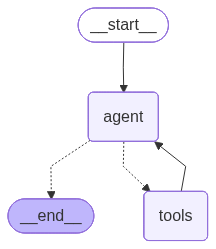

In [13]:
tool_node = ToolNode(tools)

graph_builder = StateGraph(State)
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "agent") 

graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

graph_builder.add_edge("tools", "agent") 

graph = graph_builder.compile()
graph

In [18]:
PR_NUMBER=10

In [19]:
initial_state = {
    "messages": [
        HumanMessage(
            content=f"Review PR #{PR_NUMBER}"
        )
    ],
    "pr_number": PR_NUMBER,
    "verdict":   "",
}

result = graph.invoke(initial_state)

In [20]:
result

{'messages': [HumanMessage(content='Review PR #10', additional_kwargs={}, response_metadata={}, id='74ba9b14-6f94-4ddd-a5dc-775b717297f5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 189, 'total_tokens': 230, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1d93ca07c4', 'id': 'chatcmpl-E0LsgaMdFL7z01AE6nu5yXEThoHOe', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f4ff3-fc5b-7392-9850-09ca061d0f3f-0', tool_calls=[{'name': 'get_pr_details', 'args': {}, 'id': 'call_uhFbxHjAxMES34X0mOT0h2pU', 'type': 'tool_call'}, {'name': 'get_pr_files', 'args': {}, 'id': 'call_Hbcf38k5UKN2UzfZElvluTYn', 'type': 'tool_call'}],

In [21]:
final_review = result["messages"][-1].content
print(final_review)

## 🤖 CodeSentinel Review

### ✅ What looks good
- The PR is open and ready for review.
- The author has made changes to the `orders.py` file, which seems to address some issues related to SQL queries.

### ⚠️ Issues Found
- The SQL query in `orders.py` is still vulnerable to SQL injection. The query string is being constructed using string interpolation, which is unsafe.
- The comment `# here is my password : Rahul` is inappropriate and should not be included in the codebase. It poses a security risk by exposing sensitive information.

### 🔧 Suggestions
- Use parameterized queries or prepared statements to prevent SQL injection vulnerabilities.
- Remove any sensitive information or comments that expose passwords or other confidential data from the code.

### 📊 Verdict
NEEDS CHANGES
